<a href="https://colab.research.google.com/github/lucasrasia/CNN_study/blob/main/estudo_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
from keras.models import Sequential
!pip install tensorflow

In [57]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt

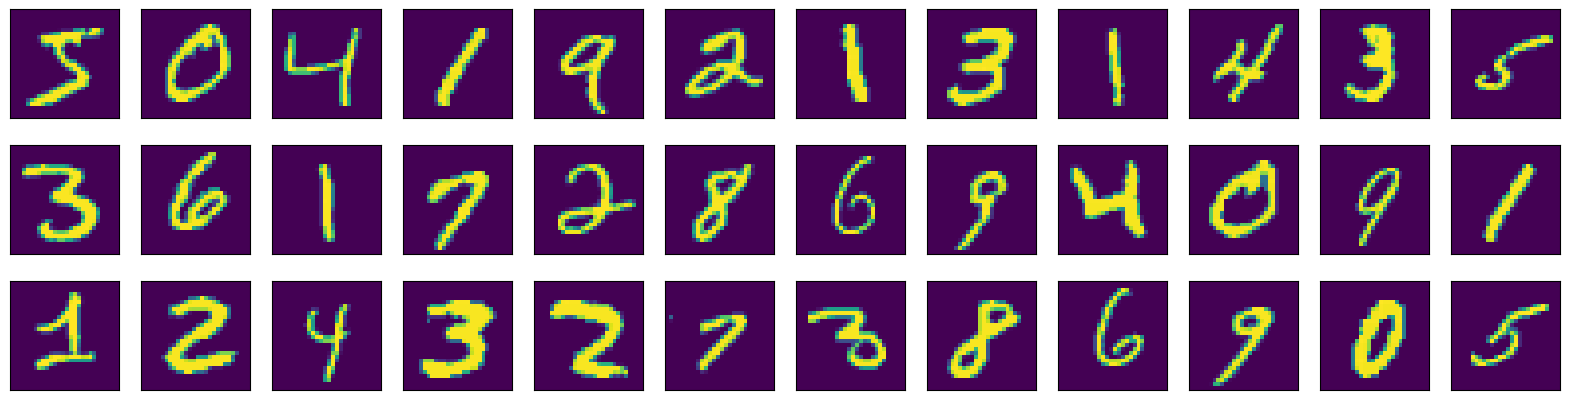

In [58]:
(x_train, y_train), (x_test, y_test)= mnist.load_data()
fig=plt.figure(figsize=(20, 5))
for i in range(36):
  ax=fig.add_subplot(3, 12, i+1, xticks=[], yticks=[])
  ax.imshow(np.squeeze(x_train[i]))

x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255

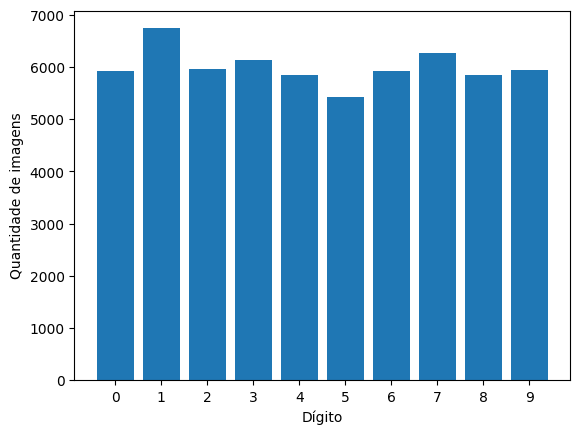

In [59]:
classes, quantidades = np.unique(y_train, return_counts=True) #return_counts=True faz o NumPy contar quantas vezes cada valor aparece

plt.bar(classes, quantidades)
plt.xlabel("Dígito")
plt.ylabel("Quantidade de imagens")
plt.xticks(range(10))
plt.show()

In [60]:
print(y_train.shape)
print(y_test.shape)
(x_train, x_valid)=x_train[:50000], x_train[50000:]
(y_train, y_valid)=y_train[:50000], y_train[50000:]
print(y_train.shape)
print(y_test.shape)
print(y_valid.shape)

(60000,)
(10000,)
(50000,)
(10000,)
(10000,)


In [66]:
model=Sequential()

model.add(Conv2D(32, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
model.add(Conv2D(128, kernel_size=(3,3), strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2))) #remover para testar

model.add(Dropout(rate=0.3)) #remover para testar

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(rate=0.3))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)